Scaricamento dei dati da Yahoo Finance...
Dati scaricati con successo! Prime righe:


Ticker,AAPL,AMZN,MSFT,TSLA
Date,,,,
2023-01-03,122.876747,85.820000,232.510544,108.099998
2023-01-04,124.144119,85.139999,222.339813,113.639999
2023-01-05,122.827621,83.120003,215.750122,110.339996
2023-01-06,127.346939,86.080002,218.292862,113.059998
2023-01-09,127.867661,87.360001,220.418213,119.769997



Rendimenti attesi annualizzati (Vettore mu):
Ticker
AAPL    0.265552
AMZN    0.331991
MSFT    0.243625
TSLA    0.478353
dtype: float64
Simulazione completata con 10.000 portafogli casuali!
--- PORTAFOGLIO OTTIMALE (MASSIMO INDICE DI SHARPE) ---
Rendimento atteso annualizzato: 28.90%
Volatilità (Rischio) annualizzata: 22.46%
Pesi ottimali dei titoli:
  AAPL: 36.63%
  MSFT: 23.08%
  TSLA: 33.07%
  AMZN: 7.22%


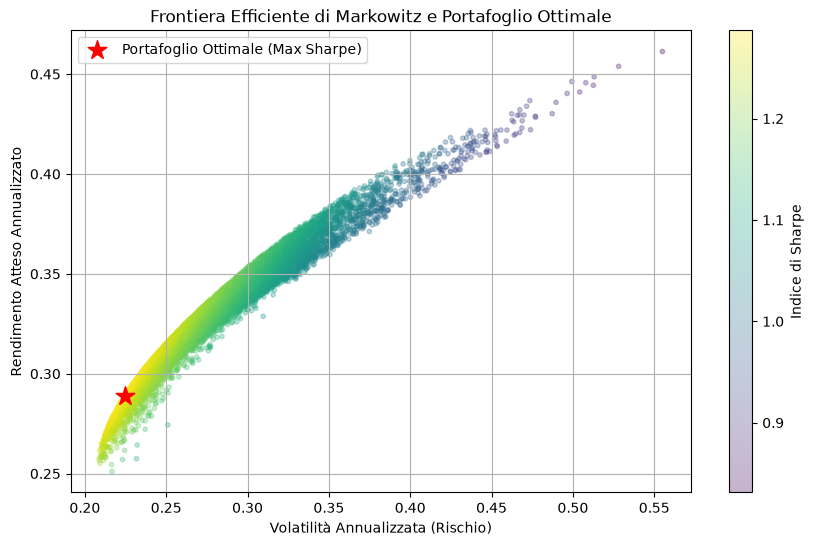

In [1]:
!pip install numpy pandas matplotlib scipy yfinance



import numpy as np
import pandas as pd
import yfinance as yf

# 1. Definiamo le azioni che vogliamo inserire nel portafoglio
tickers = ["AAPL", "MSFT", "TSLA", "AMZN"]

# 2. Scarichiamo i dati di chiusura degli ultimi 3 anni
print("Scaricamento dei dati da Yahoo Finance...")
data = yf.download(tickers, start="2023-01-01", end="2026-01-01", progress=False)["Close"]

# Rimuoviamo eventuali valori mancanti
data = data.dropna()

display(data.head())

# 3. Calcoliamo i log-rendimenti giornalieri 
# Matematicamente: r_t = ln(P_t) - ln(P_{t-1})
log_returns = np.log(data / data.shift(1)).dropna()

# 4. Calcoliamo il vettore dei rendimenti attesi e la matrice di covarianza
# Supponiamo 252 giorni di borsa in un anno
mu = log_returns.mean() * 252  # Rendimento atteso annualizzato
Sigma = log_returns.cov() * 252  # Matrice di covarianza annualizzata

print("\nRendimenti attesi annualizzati (Vettore mu):")
print(mu)




# Numero di portafogli casuali da simulare
num_portfolios = 10000

# Inizializziamo array per salvare i risultati
all_weights = np.zeros((num_portfolios, len(tickers)))
portfolio_returns = np.zeros(num_portfolios)
portfolio_volatilities = np.zeros(num_portfolios)
portfolio_sharpes = np.zeros(num_portfolios)

np.random.seed(42)  # Per riproducibilità

for i in range(num_portfolios):
  # 1. Generiamo pesi casuali
  weights = np.random.random(len(tickers))
  # 2. Normalizziamo i pesi affinché la loro somma sia 1 (vincolo di budget)
  weights /= np.sum(weights)
  all_weights[i, :] = weights

  # 3. Calcoliamo rendimento atteso del portafoglio (prodotto scalare: w^T * mu)
  portfolio_returns[i] = np.dot(weights, mu)

  # 4. Calcoliamo la volatilità (rischio) del portafoglio (forma quadratica: sqrt(w^T * Sigma * w))
  portfolio_volatilities[i] = np.sqrt(
      np.dot(weights.T, np.dot(Sigma, weights))
  )

  # 5. Calcoliamo l'Indice di Sharpe (assumendo tasso privo di rischio = 0)
  portfolio_sharpes[i] = portfolio_returns[i] / portfolio_volatilities[i]

print("Simulazione completata con 10.000 portafogli casuali!")



import matplotlib.pyplot as plt

# Troviamo l'indice del portafoglio con l'Indice di Sharpe massimo
max_sharpe_idx = np.argmax(portfolio_sharpes)

# Estraiamo le caratteristiche del portafoglio ottimo
optimal_return = portfolio_returns[max_sharpe_idx]
optimal_volatility = portfolio_volatilities[max_sharpe_idx]
optimal_weights = all_weights[max_sharpe_idx, :]

print("--- PORTAFOGLIO OTTIMALE (MASSIMO INDICE DI SHARPE) ---")
print(f"Rendimento atteso annualizzato: {optimal_return * 100:.2f}%")
print(f"Volatilità (Rischio) annualizzata: {optimal_volatility * 100:.2f}%")
print("Pesi ottimali dei titoli:")
for ticker, weight in zip(tickers, optimal_weights):
  print(f"  {ticker}: {weight * 100:.2f}%")

# Creiamo il grafico della Frontiera Efficiente
plt.figure(figsize=(10, 6))
plt.scatter(
    portfolio_volatilities,
    portfolio_returns,
    c=portfolio_sharpes,
    cmap="viridis",
    marker="o",
    s=10,
    alpha=0.3,
)
plt.colorbar(label="Indice di Sharpe")

# Mettiamo in evidenza il portafoglio ottimale con una stella rossa
plt.scatter(
    optimal_volatility,
    optimal_return,
    marker="*",
    color="red",
    s=200,
    label="Portafoglio Ottimale (Max Sharpe)",
)

plt.title("Frontiera Efficiente di Markowitz e Portafoglio Ottimale")
plt.xlabel("Volatilità Annualizzata (Rischio)")
plt.ylabel("Rendimento Atteso Annualizzato")
plt.legend(loc="upper left")
plt.grid(True)
plt.show()









